In [1]:
import re
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import keras
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import math
import nltk
from joblib import dump

In [2]:
tf. __version__

'2.19.0'

In [3]:
# Load and preprocess the dataset
data = pd.read_csv('/content/sample_data/Twitter_Data.csv')
data.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [7]:
def remove_tags(string):
    removelist = r"!*,."
    result = re.sub('<.*?>','',string)          #remove HTML tags
    result = re.sub('https://.*','',result)   #remove URLs
    result = re.sub(f"[{removelist}]", "", result)  #remove non-alphanumeric characters
    result = result.lower()
    return result

data['clean_text']=data['text'].astype(str).apply(lambda cw : remove_tags(cw))

data.head()

,textID,text,selected_text,sentiment,clean_text
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,i`d have responded if i were going
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,sooo sad i will miss you here in san diego
2,088c60f138,my boss is bullying me...,bullying me,negative,my boss is bullying me
3,9642c003ef,what interview! leave me alone,leave me alone,negative,what interview leave me alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,sons of why couldn`t they put them on the re...


In [ ]:
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))
# data['clean_text'] = data['clean_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
# data.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,textID,text,selected_text,sentiment,clean_text
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,"i`d responded, going"
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,sooo sad miss san diego!!!
2,088c60f138,my boss is bullying me...,bullying me,negative,boss bullying me...
3,9642c003ef,what interview! leave me alone,leave me alone,negative,interview! leave alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,"sons ****, couldn`t put releases already bought"


In [ ]:
# nltk.download('wordnet')

# w_tokenizer = nltk.tokenize.WhitespaceTokenizer()
# lemmatizer = nltk.stem.WordNetLemmatizer()
# def lemmatize_text(text):
#     st = ""
#     for w in w_tokenizer.tokenize(text):
#         st = st + lemmatizer.lemmatize(w) + " "
#     return st
# data['clean_text'] = data.clean_text.apply(lemmatize_text)
# data.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,textID,text,selected_text,sentiment,clean_text
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,"i`d have responded, if i were going"
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,sooo sad i will miss you here in san diego!!!
2,088c60f138,my boss is bullying me...,bullying me,negative,my bos is bullying me...
3,9642c003ef,what interview! leave me alone,leave me alone,negative,what interview! leave me alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,"son of ****, why couldn`t they put them on the..."


In [8]:
s = 0
for i in data['clean_text']:
    word_list = i.split()
    s = s + len(word_list)
print("Average length of each review : ",s/data.shape[0])

Average length of each review :  12.815108620501437


In [9]:
data['sentiment'].value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


In [ ]:
iloc[0] -> 1st row
iloc[0:] -> all rows
iloc[0:5] -> 1,2,3,4

In [10]:
pos = 0
neg = 0
for i in range(data.shape[0]):
    if data.iloc[i]['sentiment'] == 'positive':
        pos = pos + 1
for i in range(data.shape[0]):
    if data.iloc[i]['sentiment'] == 'negative':
        neg = neg + 1
neu = data.shape[0]-pos-neg
print("Percentage of reviews with positive sentiment is "+str(pos/data.shape[0]*100)+"%")
print("Percentage of reviews with negative sentiment is "+str(neg/data.shape[0]*100)+"%")
print("Percentage of reviews with neutral sentiment is "+str(neu/data.shape[0]*100)+"%")

Percentage of reviews with positive sentiment is 31.22884902296132%
Percentage of reviews with negative sentiment is 28.314107929114662%
Percentage of reviews with neutral sentiment is 40.45704304792402%


In [11]:
X = data['clean_text'].values
y = data['sentiment'].values
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Hyperparameters of the model
vocab_size = 5000 # choose based on statistics
oov_tok = ''
embedding_dim = 100
max_length = 100 # choose based on statistics, for example 150 to 200
padding_type='post'
# Tokenize and pad text sequences
tokenizer = Tokenizer(vocab_size)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

In [13]:
# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


# One-hot encode labels
num_classes = len(data['sentiment'].unique().tolist())
y_train_onehot = tf.keras.utils.to_categorical(y_train_encoded, num_classes=num_classes)
y_test_onehot = tf.keras.utils.to_categorical(y_test_encoded, num_classes=num_classes)

In [ ]:
# # Load pre-trained Word2Vec embeddings
# word2vec_model = api.load('word2vec-google-news-300')
# EMBEDDING_DIM = 300

# # Create embedding matrix
# embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
# for word, i in tokenizer.word_index.items():
#     if i >= MAX_WORDS:
#         break
#     try:
#         embedding_vector = word2vec_model[word]
#         embedding_matrix[i] = embedding_vector
#     except:
#         continue

# # Create model building function for sklearn wrapper
# def create_lstm_model(lstm_units_1=64, lstm_units_2=32,
#                      lstm_dropout_1=0.2, lstm_dropout_2=0.2,
#                      dense_units=16, dense_dropout=0.2,
#                      learning_rate=0.001):

#     model = tf.keras.Sequential([
#         Embedding(MAX_WORDS, EMBEDDING_DIM,
#                  weights=[embedding_matrix],
#                  trainable=False),
#         LSTM(lstm_units_1, return_sequences=True,
#              dropout=lstm_dropout_1),
#         LSTM(lstm_units_2, dropout=lstm_dropout_2),
#         Dense(dense_units, activation='relu'),
#         Dropout(dense_dropout),
#         Dense(3, activation='softmax')
#     ])

#     model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
#                  loss='sparse_categorical_crossentropy',metrics=['accuracy'])

#     return model

In [15]:
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM,Dropout,Bidirectional

## Try - 1

In [16]:
BATCH_SIZE = 32
model = tf.keras.Sequential([
    Embedding(input_dim=5000, output_dim=100, input_length=100),
    LSTM(128),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history = model.fit(X_train_pad, y_train_onehot,
          batch_size=BATCH_SIZE,
          epochs=5,
          validation_data=(X_test_pad, y_test_onehot))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4010 - loss: 1.0900 - val_accuracy: 0.4057 - val_loss: 1.0873
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4067 - loss: 1.0877 - val_accuracy: 0.4057 - val_loss: 1.0873
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4064 - loss: 1.0872 - val_accuracy: 0.4057 - val_loss: 1.0867
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4014 - loss: 1.0882 - val_accuracy: 0.4057 - val_loss: 1.0869
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4042 - loss: 1.0870 - val_accuracy: 0.4057 - val_loss: 1.0866


In [17]:
score, acc = model.evaluate(X_test_pad, y_test_onehot,
                            batch_size=BATCH_SIZE)
print('Test score:', score)
print('Test accuracy:', acc)

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4091 - loss: 1.0858
Test score: 1.0866353511810303
Test accuracy: 0.40567582845687866


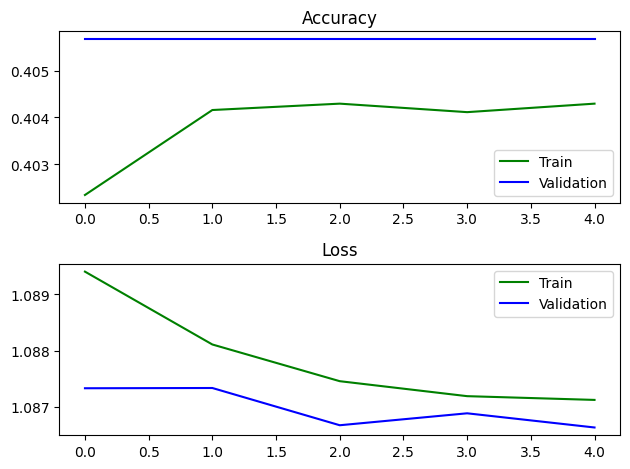

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.subplot(211)
plt.title("Accuracy")
plt.plot(history.history["accuracy"], color="g", label="Train")
plt.plot(history.history["val_accuracy"], color="b", label="Validation")
plt.legend(loc="best")
plt.subplot(212)
plt.title("Loss")
plt.plot(history.history["loss"], color="g", label="Train")
plt.plot(history.history["val_loss"], color="b", label="Validation")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [19]:

# Save the trained model
model.save('sentiment_model_1.keras')
dump(tokenizer, 'tokenizer.joblib')

['tokenizer.joblib']

In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from joblib import load
import re
import nltk
from nltk.tokenize import WhitespaceTokenizer
from nltk.stem import WordNetLemmatizer

def preprocess_text(text):
    # Remove tags and URLs
    text = re.sub('','',text)          #remove HTML tags
    text = re.sub('https://.*','',text)   #remove URLs
    text = text.lower()


    return text

def predict_sentiment(text, model_path='/content/sentiment_model_1.keras', tokenizer_path='/content/tokenizer.joblib'):
    # Load the model and tokenizer
    model = tf.keras.models.load_model(model_path)
    tokenizer = load(tokenizer_path)

    # Preprocess the input text
    cleaned_text = preprocess_text(text)

    # Tokenize and pad the text
    sequences = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequences, maxlen=75, padding='post', truncating='post')

    # Make prediction
    prediction = model.predict(padded, verbose=0)
    sentiment_labels = ['negative', 'neutral', 'positive']
    predicted_sentiment = sentiment_labels[prediction.argmax()]
    confidence = float(prediction.max())

    return {
        'sentiment': predicted_sentiment,
        'confidence': confidence,
        'probabilities': {
            label: float(prob)
            for label, prob in zip(sentiment_labels, prediction[0])
        }
    }

In [21]:
# Example usage
text = "I absolutely love this new product! It works great!"
result = predict_sentiment(text)
print(f"Text: {text}")
print(f"Sentiment: {result['sentiment']}")
print(f"Confidence: {result['confidence']:.2%}")
print("\nProbabilities:")
for sentiment, prob in result['probabilities'].items():
    print(f"{sentiment}: {prob:.2%}")

Text: I absolutely love this new product! It works great!
Sentiment: neutral
Confidence: 40.45%

Probabilities:
negative: 28.55%
neutral: 40.45%
positive: 31.00%


In [22]:
# Example usage
text = "Because none of us is as dumb as all of us."
result = predict_sentiment(text)
print(f"Text: {text}")
print(f"Sentiment: {result['sentiment']}")
print(f"Confidence: {result['confidence']:.2%}")
print("\nProbabilities:")
for sentiment, prob in result['probabilities'].items():
    print(f"{sentiment}: {prob:.2%}")

Text: Because none of us is as dumb as all of us.
Sentiment: neutral
Confidence: 40.45%

Probabilities:
negative: 28.55%
neutral: 40.45%
positive: 31.00%


## Try - 2

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [24]:
HIDDEN_LAYER_SIZE = 128
BATCH_SIZE = 32
NUM_EPOCHS = 10
DROPOUT_RATE = 0.5
LEARNING_RATE = 0.001
print('Build model...')
model = Sequential()
# Embedding layer
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    input_length=max_length))

# First LSTM layer with dropout
model.add(Bidirectional(LSTM(HIDDEN_LAYER_SIZE,
                             return_sequences=True)))
model.add(Dropout(DROPOUT_RATE))

# Second LSTM layer
model.add(Bidirectional(LSTM(HIDDEN_LAYER_SIZE)))
model.add(Dropout(DROPOUT_RATE))

# Dense layer for feature extraction
model.add(Dense(64, activation='relu'))
model.add(Dropout(DROPOUT_RATE))

# Output layer
model.add(Dense(num_classes, activation='softmax'))

# summary of our model.
model.summary()

# Compile the model.
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

Build model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Create callbacks for better training
def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=0.0001
        )
    ]

In [26]:
print('Train...')
history = model.fit(
        X_train_pad, y_train_onehot,
        batch_size=BATCH_SIZE,
        epochs=NUM_EPOCHS,
        validation_data=(X_test_pad, y_test_onehot),
        callbacks=get_callbacks(),
        shuffle=True
    )

Train...
Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.4950 - loss: 0.9825 - val_accuracy: 0.6924 - val_loss: 0.7283 - learning_rate: 0.0010
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7353 - loss: 0.6660 - val_accuracy: 0.7146 - val_loss: 0.6747 - learning_rate: 0.0010
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7860 - loss: 0.5657 - val_accuracy: 0.7158 - val_loss: 0.6863 - learning_rate: 0.0010
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8122 - loss: 0.5046 - val_accuracy: 0.7089 - val_loss: 0.7259 - learning_rate: 0.0010
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8357 - loss: 0.4461 - val_accuracy: 0.7044 - val_loss: 0.8170 - learning_rate: 0.0010
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8772 - loss: 0.3564 - val_accuracy: 0.6980 - val_loss: 0.9164 - learning_rate: 2.0000e-04
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accurac

In [27]:
score, acc = model.evaluate(X_test_pad, y_test_onehot,
                            batch_size=BATCH_SIZE)
print('Test score:', score)
print('Test accuracy:', acc)

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7133 - loss: 0.6921
Test score: 0.6863403916358948
Test accuracy: 0.715844988822937


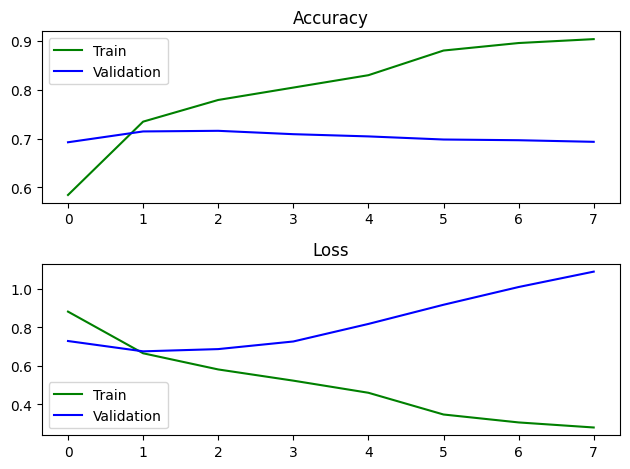

In [28]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.subplot(211)
plt.title("Accuracy")
plt.plot(history.history["accuracy"], color="g", label="Train")
plt.plot(history.history["val_accuracy"], color="b", label="Validation")
plt.legend(loc="best")
plt.subplot(212)
plt.title("Loss")
plt.plot(history.history["loss"], color="g", label="Train")
plt.plot(history.history["val_loss"], color="b", label="Validation")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [29]:

# Save the trained model
model.save('sentiment_model_2.keras')
dump(tokenizer, 'tokenizer.joblib')

['tokenizer.joblib']

In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from joblib import load
import re
import nltk
from nltk.tokenize import WhitespaceTokenizer
from nltk.stem import WordNetLemmatizer

def preprocess_text(text):
    # Remove tags and URLs
    text = re.sub('','',text)          #remove HTML tags
    text = re.sub('https://.*','',text)   #remove URLs
    text = text.lower()


    return text

def predict_sentiment(text, model_path='sentiment_model_2.keras', tokenizer_path='tokenizer.joblib'):
    # Load the model and tokenizer
    model = tf.keras.models.load_model(model_path)
    tokenizer = load(tokenizer_path)

    # Preprocess the input text
    cleaned_text = preprocess_text(text)

    # Tokenize and pad the text
    sequences = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequences, maxlen=75, padding='post', truncating='post')

    # Make prediction
    prediction = model.predict(padded, verbose=0)
    sentiment_labels = ['negative', 'neutral', 'positive']
    predicted_sentiment = sentiment_labels[prediction.argmax()]
    confidence = float(prediction.max())

    return {
        'sentiment': predicted_sentiment,
        'confidence': confidence,
        'probabilities': {
            label: float(prob)
            for label, prob in zip(sentiment_labels, prediction[0])
        }
    }

In [31]:
# Example usage
text = "I absolutely love this new product! It works great!"
result = predict_sentiment(text)
print(f"Text: {text}")
print(f"Sentiment: {result['sentiment']}")
print(f"Confidence: {result['confidence']:.2%}")
print("\nProbabilities:")
for sentiment, prob in result['probabilities'].items():
    print(f"{sentiment}: {prob:.2%}")

Text: I absolutely love this new product! It works great!
Sentiment: positive
Confidence: 99.06%

Probabilities:
negative: 0.06%
neutral: 0.87%
positive: 99.06%


In [32]:
# Example usage
text = "Because none of us is as dumb as all of us."
result = predict_sentiment(text)
print(f"Text: {text}")
print(f"Sentiment: {result['sentiment']}")
print(f"Confidence: {result['confidence']:.2%}")
print("\nProbabilities:")
for sentiment, prob in result['probabilities'].items():
    print(f"{sentiment}: {prob:.2%}")

Text: Because none of us is as dumb as all of us.
Sentiment: negative
Confidence: 67.40%

Probabilities:
negative: 67.40%
neutral: 29.95%
positive: 2.65%
